In [ ]:
!pip install pennylane

#IMDB Top 250 Movies

In [ ]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, mean_squared_error, mean_absolute_error

# Load and preprocess data
df = pd.read_csv('/content/IMDB Top 250 Movies.csv')
df.dropna(inplace=True)
user_movie_df = df.pivot_table("rating", "year", "name")

# Define a quantum circuit with 4 qubits
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_corr(params):


    # Embed parameters using AngleEmbedding
    qml.templates.AngleEmbedding(params[:n_qubits], wires=range(n_qubits), rotation="X")

    # Apply Hadamard gates on each qubit
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Apply RX and RY rotations
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
        qml.RY(params[i + n_qubits], wires=i)

    # Apply Controlled-Z gates between qubits
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])

    # Apply entangling CNOT gates
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Measure the expectation of the PauliZ tensor product
    return qml.expval(qml.prod(*[qml.PauliZ(i) for i in range(n_qubits)]))

# Choose a movie for which to calculate correlations
movie_name = input("Enter movie name: ")
movie_name_df = user_movie_df[movie_name]

# Create a ground truth correlation matrix or rating matrix (this is just an example)
ground_truth_matrix = user_movie_df.corr().fillna(0)

# Calculate quantum correlations for each movie
movie_correlations = []
for column in user_movie_df.columns:
    if column != movie_name:
        params = np.random.uniform(0, 2 * np.pi, size=2 * n_qubits)
        correlation = quantum_corr(params)
        movie_correlations.append((column, correlation))

# Sort and display the top correlated movies
movie_correlations.sort(key=lambda x: x[1], reverse=True)
top_correlated = movie_correlations[:5]

print("\nTop correlated movies:")
for movie, correlation in top_correlated:
    print(f"{movie}: {correlation:.4f}")

# Extract the correlations from the top correlated movies
quantum_correlations = [correlation for movie, correlation in top_correlated]

# Extract the ground truth correlations from the ground truth matrix
ground_truth_correlations = [ground_truth_matrix.loc[movie_name, movie] for movie, _ in top_correlated]

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error, mean_squared_error

#accuracy = accuracy_score(quantum_correlations, ground_truth_correlations)
#precision = precision_score(quantum_correlations, ground_truth_correlations, average='weighted')
mae = mean_absolute_error(quantum_correlations, ground_truth_correlations)
mse = mean_squared_error(quantum_correlations, ground_truth_correlations)
rmse = np.sqrt(mse)

#print(f"\nAccuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Enter movie name: Ikiru

Top correlated movies:
The Green Mile: 0.9742
Stand by Me: 0.9634
Batman Begins: 0.9333
Logan: 0.8517
Chinatown: 0.8252
MAE: 0.9096
MSE: 0.8310
Root Mean Squared Error (RMSE): 0.9116


#MovieLens 10k

In [ ]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, mean_squared_error, mean_absolute_error

# Load and preprocess data
movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')
df = movies.merge(ratings, how="left", on="movieId")
df.dropna(inplace=True)

user_movie_df = df.pivot_table("rating", "userId", "title")

# Define a quantum circuit with 4 qubits
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_corr(params):

    # Embed parameters using AngleEmbedding
    qml.templates.AngleEmbedding(params[:n_qubits], wires=range(n_qubits), rotation="X")

    # Apply Hadamard gates on each qubit
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Apply RX and RY rotations
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
        qml.RY(params[i + n_qubits], wires=i)

    # Apply Controlled-Z gates between qubits
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])

    # Apply entangling CNOT gates
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Measure the expectation of the PauliZ tensor product
    return qml.expval(qml.prod(*[qml.PauliZ(i) for i in range(n_qubits)]))



# Choose a movie for which to calculate correlations
movie_name = input("Enter movie name: ")
movie_name_df = user_movie_df[movie_name]

# Create a ground truth correlation matrix or rating matrix (this is just an example)
ground_truth_matrix = user_movie_df.corr()

# Calculate quantum correlations for each movie
movie_correlations = []
for column in user_movie_df.columns:
    if column != movie_name:
        #params = np.random.uniform(0, 2 * np.pi, size=2)
        params = np.random.uniform(0, 2 * np.pi, size=2 * n_qubits)
        correlation = quantum_corr(params)
        movie_correlations.append((column, correlation))

# Sort and display the top correlated movies
movie_correlations.sort(key=lambda x: x[1], reverse=True)
top_correlated = movie_correlations[:5]

print("\nTop correlated movies:")
for movie, correlation in top_correlated:
    print(f"{movie}: {correlation:.4f}")

# Extract the ground truth correlations from the ground truth matrix
ground_truth_correlations = [
    ground_truth_matrix.loc[movie_name, movie]
    if pd.notna(ground_truth_matrix.loc[movie_name, movie]) else 0
    for movie, _ in top_correlated
]

# Ensure no NaNs in quantum_correlations or ground_truth_correlations
quantum_correlations = np.nan_to_num(quantum_correlations, nan=0.0)
ground_truth_correlations = np.nan_to_num(ground_truth_correlations, nan=0.0)

# Calculate metrics
mae = mean_absolute_error(quantum_correlations, ground_truth_correlations)
mse = mean_squared_error(quantum_correlations, ground_truth_correlations)
rmse = np.sqrt(mse)

print(f"\nMAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Enter movie name: Heat (1995)

Top correlated movies:
Arthur 2: On the Rocks (1988): 0.9150
Pompatus of Love, The (1996): 0.8831
Big Stan (2007): 0.8742
Hope Floats (1998): 0.8709
Must Love Dogs (2005): 0.8602

MAE: 0.9238
MSE: 0.8543
RMSE: 0.9243


#Supermarket sales

In [ ]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load and preprocess data
df = pd.read_csv('/content/supermarket_sales - Sheet1.csv')
df.dropna(inplace=True)
user_product_df = df.pivot_table("Unit price", "Rating", "Product line")


# Define a quantum circuit with 5 qubits
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_corr(params):

    # Embed parameters using AngleEmbedding
    qml.templates.AngleEmbedding(params[:n_qubits], wires=range(n_qubits), rotation="X")

    # Apply Hadamard gates on each qubit
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Apply RX and RY rotations
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
        qml.RY(params[i + n_qubits], wires=i)

    # Apply Controlled-Z gates between qubits
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])

    # Apply entangling CNOT gates
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Measure the expectation of the PauliZ tensor product
    return qml.expval(qml.prod(*[qml.PauliZ(i) for i in range(n_qubits)]))


# Choose a product for which to calculate correlations
product_name = input("Enter Product name: ")

if product_name not in user_product_df.columns:
    print("Error: Product name not found in dataset.")
    exit()

# Create a ground truth correlation matrix
ground_truth_matrix = user_product_df.corr().fillna(0)

# Calculate quantum correlations for each product
product_correlations = []
for column in user_product_df.columns:
    if column != product_name:
        # Generate random parameters for the quantum circuit
        params = np.random.uniform(0, 2 * np.pi, size=2 * n_qubits)
        correlation = quantum_corr(params)
        product_correlations.append((column, correlation))

# Sort and display the top correlated products
product_correlations.sort(key=lambda x: x[1], reverse=True)
top_correlated = product_correlations[:5]

print("\nTop correlated products:")
for product, correlation in top_correlated:
    print(f"{product}: {correlation:.4f}")

# Extract quantum correlations
quantum_correlations = [correlation for product, correlation in top_correlated]

# Extract the ground truth correlations from the ground truth matrix
ground_truth_correlations = [ground_truth_matrix.loc[product_name, product] for product, _ in top_correlated]

# Calculate error metrics
mae = mean_absolute_error(quantum_correlations, ground_truth_correlations)
mse = mean_squared_error(quantum_correlations, ground_truth_correlations)
rmse = np.sqrt(mse)

# Display error metrics
print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Enter Product name: Health and beauty

Top correlated products:
Sports and travel: 0.8259
Fashion accessories: 0.1902
Home and lifestyle: 0.1030
Electronic accessories: 0.0304
Food and beverages: -0.1732

Mean Absolute Error (MAE): 0.3049
Mean Squared Error (MSE): 0.1616
Root Mean Squared Error (RMSE): 0.4020


#BigBasket Products

In [ ]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, mean_squared_error, mean_absolute_error

# Load and preprocess data
df = pd.read_csv('/content/BigBasket Products.csv')
df.dropna(inplace=True)
user_product_df = df.pivot_table("sale_price", "rating", "product")


# Define a quantum circuit with 4 qubits
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_corr(params):

    # Embed parameters using AngleEmbedding
    qml.templates.AngleEmbedding(params[:n_qubits], wires=range(n_qubits), rotation="X")

    # Apply Hadamard gates on each qubit
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Apply RX and RY rotations
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
        qml.RY(params[i + n_qubits], wires=i)

    # Apply Controlled-Z gates between qubits
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])

    # Apply entangling CNOT gates
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Measure the expectation of the PauliZ tensor product
    return qml.expval(qml.prod(*[qml.PauliZ(i) for i in range(n_qubits)]))


# Choose a movie for which to calculate correlations
product_name = input("Enter Product name: ")
product_name_df = user_product_df[product_name]

# Create a ground truth correlation matrix or rating matrix (this is just an example)
ground_truth_matrix = user_product_df.corr().fillna(0)

# Calculate quantum correlations for each product
product_correlations = []
for column in user_product_df.columns:
    if column != product_name:
        # Generate random parameters for the quantum circuit
        params = np.random.uniform(0, 2 * np.pi, size=2 * n_qubits)
        correlation = quantum_corr(params)
        product_correlations.append((column, correlation))

# Sort and display the top correlated movies
product_correlations.sort(key=lambda x: x[1], reverse=True)
top_correlated = product_correlations[:5]

print("\nTop correlated products:")
for product, correlation in top_correlated:
    print(f"{product}: {correlation:.4f}")

# Extract the correlations from the top correlated movies
quantum_correlations = [correlation for product, correlation in top_correlated]

# Extract the ground truth correlations from the ground truth matrix
ground_truth_correlations = [ground_truth_matrix.loc[product_name, product] for product, _ in top_correlated]

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(quantum_correlations, ground_truth_correlations)
mse = mean_squared_error(quantum_correlations, ground_truth_correlations)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Enter Product name: Tamarind/Hunisehannu

Top correlated products:
Cream Of Tartar: 0.9988
Grooming Solutions Kit: 0.9967
Toilet Seat Sanitizer + Deodoriser: 0.9931
Stainless Steel Tomato Knife - 8 Inch, Silver: 0.9927
Face Shield A4 Size: 0.9922
MAE: 0.9947
MSE: 0.9894
RMSE: 0.9947


#Quantum Circuit

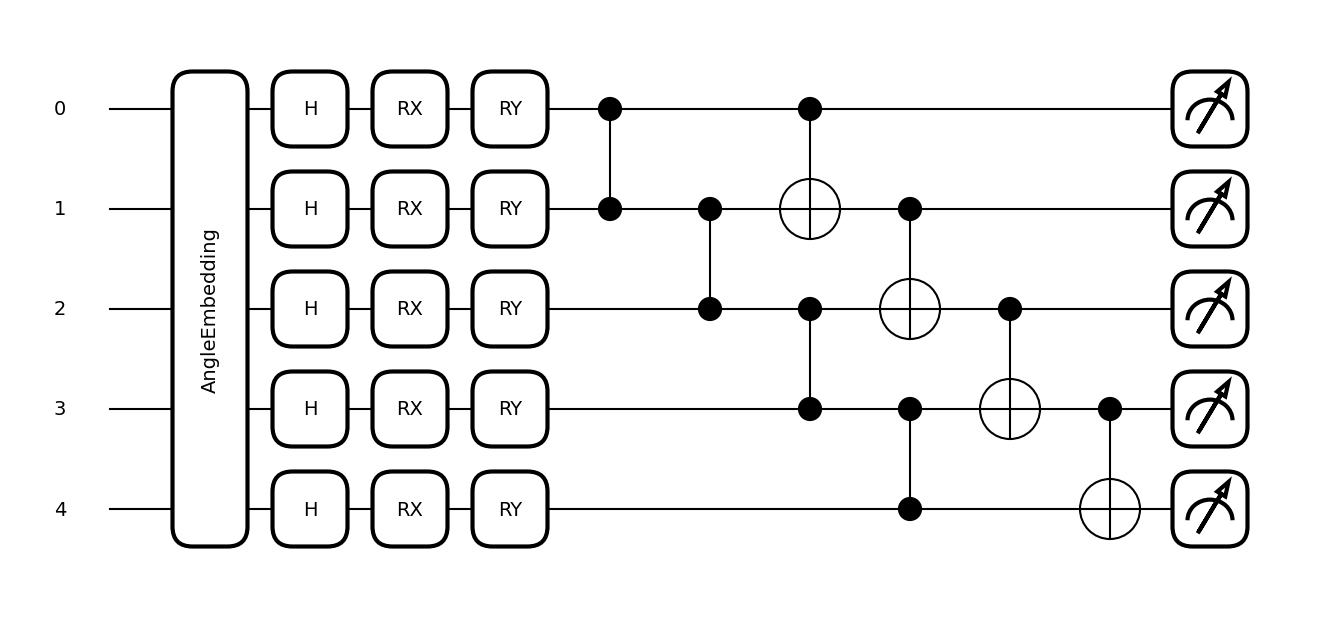

In [ ]:
# Generate random parameters for the circuit

params = np.random.uniform(0, 2 * np.pi, size=4 * n_qubits)

# Draw the circuit
#print(circuit.draw())

import matplotlib.pyplot as plt
drawer = qml.draw_mpl(quantum_corr)
drawer(params)
plt.show()